In [19]:
import os
import sys

# Instala as dependências diretamente no ambiente atual
!{sys.executable} -m pip install scikit-learn pandas seaborn matplotlib mlflow fastapi uvicorn

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('../')

from src.data_prep import load_data, clean_data

# Carregar dados
df_raw = load_data('../data/raw/bank-additional-full.csv')
print(f"Dimensões originais: {df_raw.shape}")
df_raw.head()

Dimensões originais: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Dimensões após remoção de leakage: (41188, 20)
Taxa de conversão média (Baseline Global): 11.27%


/var/folders/wb/5sjrfc3x26d1j18tmc2p5mp80000gn/T/ipykernel_6111/2431733000.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


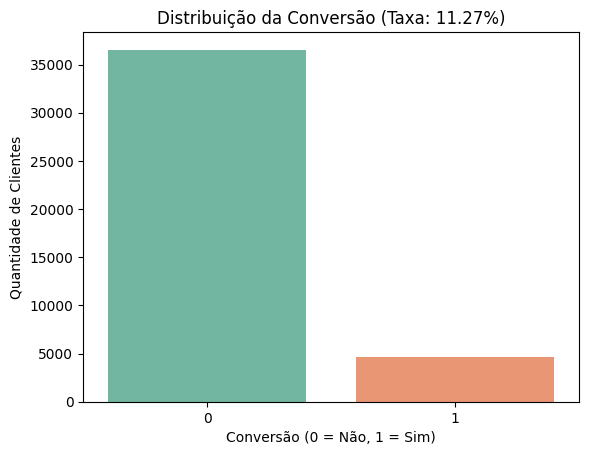

In [21]:
# Limpeza e remoção de 'duration' (leakage)
df = clean_data(df_raw)
print(f"Dimensões após remoção de leakage: {df.shape}")

# Distribuição da Taxa de Conversão (Target)
conversion_rate = df['target'].mean()
print(f"Taxa de conversão média (Baseline Global): {conversion_rate:.2%}")

# Visualização
sns.countplot(data=df, x='target', palette='Set2')
plt.title(f'Distribuição da Conversão (Taxa: {conversion_rate:.2%})')
plt.xlabel('Conversão (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Clientes')
plt.show()


/var/folders/wb/5sjrfc3x26d1j18tmc2p5mp80000gn/T/ipykernel_6111/195781806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_conv.index, y=job_conv.values, palette='Blues_r')


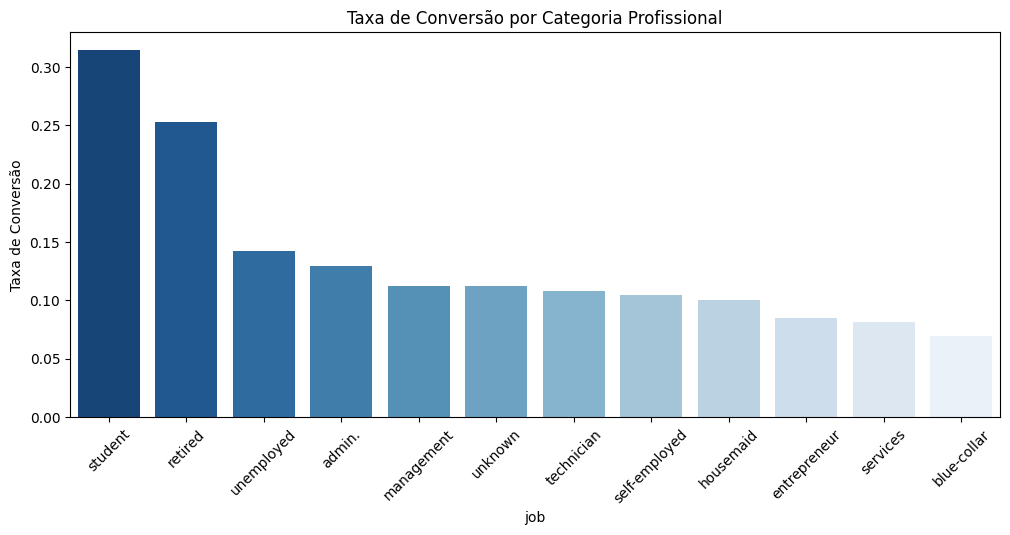

In [22]:
# Conversão por Tipo de Emprego (Job)
plt.figure(figsize=(12, 5))
job_conv = df_raw.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
sns.barplot(x=job_conv.index, y=job_conv.values, palette='Blues_r')
plt.xticks(rotation=45)
plt.title('Taxa de Conversão por Categoria Profissional')
plt.ylabel('Taxa de Conversão')
plt.show()

--- RESULTADOS DA ETAPA 3 ---
Taxa de Conversão Baseline (Regra Fixa): 4.98%
Taxa de Conversão Thompson Sampling:     17.34%
Ganho Relativo de Conversão:             248.19%


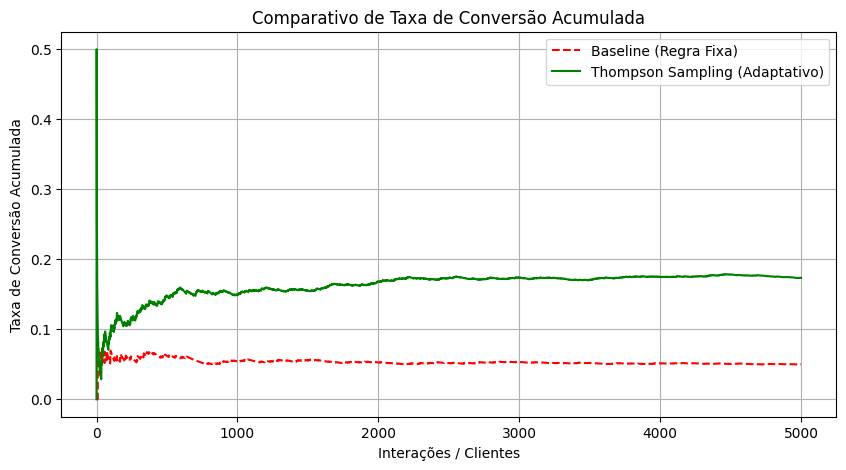

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.models import DeterministicBaseline, ThompsonSamplingBandit

# Configuração da Simulação
np.random.seed(42)
n_simulations = 5000
n_arms = 4
arm_names = ["Depósito a Prazo", "Cartão de Crédito", "Empréstimo Pessoal", "Seguro de Vida"]

# Taxas de conversão reais (desconhecidas pelo modelo no início)
# O braço 0 (Depósito) é a melhor oferta real (18% de conversão)
true_conversion_rates = [0.18, 0.05, 0.08, 0.03]

# 1. Execução do Baseline (Regra Fixa: oferece sempre o braço 1 - Cartão de Crédito)
baseline = DeterministicBaseline(fixed_action=1)
baseline_rewards = []
for _ in range(n_simulations):
    action = baseline.select_action()
    reward = 1 if np.random.rand() < true_conversion_rates[action] else 0
    baseline_rewards.append(reward)

# 2. Execução do Algoritmo Adaptativo (Thompson Sampling)
bandit = ThompsonSamplingBandit(n_arms=n_arms)
bandit_rewards = []
chosen_actions = []

for _ in range(n_simulations):
    action = bandit.select_action()
    reward = 1 if np.random.rand() < true_conversion_rates[action] else 0
    bandit.update(action, reward)
    
    bandit_rewards.append(reward)
    chosen_actions.append(action)

# Métricas Comparativas
baseline_acc_conv = np.mean(baseline_rewards)
bandit_acc_conv = np.mean(bandit_rewards)

print(f"--- RESULTADOS DA ETAPA 3 ---")
print(f"Taxa de Conversão Baseline (Regra Fixa): {baseline_acc_conv:.2%}")
print(f"Taxa de Conversão Thompson Sampling:     {bandit_acc_conv:.2%}")
print(f"Ganho Relativo de Conversão:             {((bandit_acc_conv - baseline_acc_conv)/baseline_acc_conv):.2%}")

# Gráfico de Evolução da Conversão Acumulada
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(baseline_rewards) / np.arange(1, n_simulations + 1), label='Baseline (Regra Fixa)', color='red', linestyle='--')
plt.plot(np.cumsum(bandit_rewards) / np.arange(1, n_simulations + 1), label='Thompson Sampling (Adaptativo)', color='green')
plt.title('Comparativo de Taxa de Conversão Acumulada')
plt.xlabel('Interações / Clientes')
plt.ylabel('Taxa de Conversão Acumulada')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Criando o Golden Set com 5 perfis de clientes de teste
golden_set = pd.DataFrame([
    {"cliente_id": 101, "age": 32, "job": "technician", "balance": 1500, "housing": "yes"},
    {"cliente_id": 102, "age": 58, "job": "retired", "balance": 12000, "housing": "no"},
    {"cliente_id": 103, "age": 24, "job": "student", "balance": 300, "housing": "no"},
    {"cliente_id": 104, "age": 45, "job": "management", "balance": 4500, "housing": "yes"},
    {"cliente_id": 105, "age": 39, "job": "blue-collar", "balance": 800, "housing": "yes"}
])

# Gerando recomendações para o Golden Set
recomendacoes = []
for idx, row in golden_set.iterrows():
    # O modelo escolhe a melhor oferta adaptativa baseada no aprendizado do histórico
    acao_recomendada = bandit.select_action()
    oferta = arm_names[acao_recomendada]
    
    recomendacoes.append({
        "ID Cliente": row["cliente_id"],
        "Profissão": row["job"],
        "Saldo em Conta": f"€{row['balance']}",
        "Oferta Recomendada": oferta,
        "Decisão Justificada": "Oferta com maior propensão de conversão segundo o aprendizado posterior da distribuição."
    })

df_golden_set = pd.DataFrame(recomendacoes)
df_golden_set

,ID Cliente,Profissão,Saldo em Conta,Oferta Recomendada,Decisão Justificada
0,101,technician,€1500,Depósito a Prazo,Oferta com maior propensão de conversão segund...
1,102,retired,€12000,Depósito a Prazo,Oferta com maior propensão de conversão segund...
2,103,student,€300,Depósito a Prazo,Oferta com maior propensão de conversão segund...
3,104,management,€4500,Depósito a Prazo,Oferta com maior propensão de conversão segund...
4,105,blue-collar,€800,Depósito a Prazo,Oferta com maior propensão de conversão segund...


In [25]:
import os
import sys
from pathlib import Path

# Garante o uso do backend local de arquivos
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import mlflow
import numpy as np
from src.models import DeterministicBaseline, ThompsonSamplingBandit

# Encontra a raiz do projeto e aponta para a pasta mlruns
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
mlruns_dir = project_root / "mlruns"

# Força o MLflow a usar a pasta mlruns na raiz
mlflow.set_tracking_uri(mlruns_dir.as_uri())
mlflow.set_experiment("Datathon_Adaptive_Offer_Engine")

# --- EXPERIMENTO 1: Baseline Determinístico ---
with mlflow.start_run(run_name="Deterministic_Baseline"):
    mlflow.log_param("model_type", "DeterministicBaseline")
    mlflow.log_param("fixed_arm", 1)
    
    mlflow.log_metric("conversion_rate", float(baseline_acc_conv))
    mlflow.log_metric("total_simulations", n_simulations)
    print("✓ Run do Baseline registrado com sucesso!")

# --- EXPERIMENTO 2: Thompson Sampling (Adaptativo) ---
with mlflow.start_run(run_name="Thompson_Sampling_Bandit"):
    mlflow.log_param("model_type", "ThompsonSamplingBandit")
    mlflow.log_param("n_arms", n_arms)
    mlflow.log_param("prior_type", "Beta(1,1) Uniform")
    
    for i in range(n_arms):
        mlflow.log_param(f"arm_{i}_alpha_final", float(bandit.alpha[i]))
        mlflow.log_param(f"arm_{i}_beta_final", float(bandit.beta[i]))
    
    mlflow.log_metric("conversion_rate", float(bandit_acc_conv))
    mlflow.log_metric("relative_gain", float((bandit_acc_conv - baseline_acc_conv) / baseline_acc_conv))
    mlflow.log_metric("total_simulations", n_simulations)
    
    print("✓ Run do Thompson Sampling registrado com sucesso!")

✓ Run do Baseline registrado com sucesso!
✓ Run do Thompson Sampling registrado com sucesso!


In [26]:
import os
import sys
from pathlib import Path

# Localiza a raiz do projeto
project_root = Path.cwd().parent if Path.cwd().name in ['notebooks', 'notebook'] else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import mlflow
from src.models import DeterministicBaseline, ThompsonSamplingBandit

# Define o caminho exato do banco de dados SQLite na RAIZ do projeto
db_path = project_root / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}")

# Define e grava o experimento
mlflow.set_experiment("Datathon_Adaptive_Offer_Engine")

with mlflow.start_run(run_name="Deterministic_Baseline"):
    mlflow.log_param("model_type", "DeterministicBaseline")
    mlflow.log_param("fixed_arm", 1)
    mlflow.log_metric("conversion_rate", float(baseline_acc_conv))

with mlflow.start_run(run_name="Thompson_Sampling_Bandit"):
    mlflow.log_param("model_type", "ThompsonSamplingBandit")
    mlflow.log_param("n_arms", n_arms)
    mlflow.log_metric("conversion_rate", float(bandit_acc_conv))
    mlflow.log_metric("relative_gain", float((bandit_acc_conv - baseline_acc_conv) / baseline_acc_conv))

print("✓ Experimentos salvos com sucesso no SQLite local!")

2026/08/11 22:18:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/11 22:18:54 INFO mlflow.store.db.utils: Updating database tables
2026/08/11 22:18:57 INFO mlflow.tracking.fluent: Experiment with name 'Datathon_Adaptive_Offer_Engine' does not exist. Creating a new experiment.


✓ Experimentos salvos com sucesso no SQLite local!
